 # **California Vegetation Treatments Tracking System**

California's wildfire risk is shaped not just by ignitions, but by ongoing
vegetation treatment work — prescribed fire, mechanical fuels reduction,
targeted grazing, timber harvest, and tree planting — carried out by federal,
state, tribal, and private organizations across the state. The **Interagency
Tracking System (ITS): Activity Report** consolidates these activities into a
single statewide layer, recording who performed each treatment, where, when,
what type, on what land ownership, and how much area was affected.                                                                                                                                                              
This notebook explores the full ITS V2.0 dataset (~168,000 activity records)
served as a public ArcGIS Feature Service:                                                                                                                             
- **Service:** `https://sparcal.sdsc.edu/arcgis/rest/services/Hosted/ITS_V2_0_Activity_webmap_gdb/FeatureServer/0`
- **Coverage:** California, 2021 onward (with planned activities through 2030)
- **Geometry:** Point per activity; native projection EPSG:3857 (Web Mercator), served as EPSG:4326 (WGS84) on request


You can ask for treatments by:                                                                                                                                         
- **Activity category** — prescribed fire, mechanical fuels reduction,  grazing, timber harvest, tree planting               
- **Administering organization** — CAL FIRE, U.S. Forest Service, BLM,
National Park Service, CAL TRANS, and ~25 others   
- **County, region, ownership group, vegetation type, status, or year**                                                                                               
Each query returns a GeoDataFrame and an automatically-rendered map; the
points can be colored by any categorical field (e.g., `administering_org`,
`activity_cat`) with a legend on the side.

            
No coding needed — just type a natural-language question into each `%%ask` cell.                                             


####   **Choose your language model**
  
  Argus is model-agnostic — you can plug in any of the major LLM providers and Argus will work. Pick whichever you have an API key for. To switch, comment out the active `LLM = {...}` block and uncomment the one you want.

  **This notebook defaults to GLM-5 via the National Research Platform** (free for NRP users, strong on scientific tool use). If you don't have NRP
  access, swap in OpenAI, Anthropic, or Google — they all work.

  **Before you run the cell: save your API key as a Colab Secret**

  Argus reads your API key from a Colab Secret, not from the notebook itself — that keeps the key out of your saved file and out of anyone you share the
  notebook with.

  1. Click the 🔑 key icon in the left sidebar (**Secrets**).
  2. Click **+ Add new secret**.
  3. Set the **Name** to match the `api_key_env` value in your `LLM` block:
     - `NRP_API_KEY` for GLM-5 on NRP
     - `OPENAI_API_KEY` for GPT-5.5
     - `ANTHROPIC_API_KEY` for Claude Sonnet/Opus
     - `GOOGLE_API_KEY` for Gemini

  4. Paste your key into the **Value** field.
  5. Toggle **Notebook access** on for this notebook.

  If the key isn't set (or notebook access is off), Argus will fail with an authentication error when it tries to call the model.

  ### Supported models

  | Provider | Models |
  |---|---|
  | OpenAI | GPT-5.5, GPT-5.4 |
  | Anthropic | Claude Opus 4.7, Opus 4.6 |
  | Google | Gemini 3.5 Flash |
  | Z.ai | GLM-5, GLM-5.1 |
  | Moonshot | Kimi-K2.6 |
  | MiniMax | MiniMax-M2.7 |
  | DeepSeek | DeepSeek-V4 Flash |

  Any model in this list should run Argus notebooks correctly. The four pre-configured blocks below are starter templates; for the others, follow the
  same `LLM = {...}` pattern with the right `model` and `api_key_env`.

In [ ]:
# Use GLM-5 from National Research Platform
LLM = {
    "model": "glm-5",
    "url": "https://ellm.nrp-nautilus.io/v1",
    "api_key_env": "NRP_API_KEY",
}

# Use GPT-5.5 from OpenAI
# LLM = {
#     "model": "gpt-5.5",
#     "api_key_env": "OPENAI_API_KEY",
# }

# Use Claude Sonnet 4.6 from Anthropic
# LLM = {
#     "model": "claude-sonnet-4-6",
#     "api_key_env": "ANTHROPIC_API_KEY",
#     "flavor": "anthropic",
# }

# Use Gemini 3.5 Flash from Google
# LLM = {
#     "model": "gemini-3.5-flash",
#     "api_key_env": "GOOGLE_API_KEY",
#     "flavor": "gemini",
# }


#### **Install Argus from GitHub Repo**

In [ ]:
import urllib.request
exec(urllib.request.urlopen(
    'https://raw.githubusercontent.com/klinucsd/sage/main/argus_colab/install.py'
).read().decode(), globals())

ARGUS bootstrap starting...
  ✓ Wrote LLM config to /root/.deepagents/config.toml (added default params for 1 ChatOpenAI provider(s))
  ✓ Loaded NRP_API_KEY from Colab Secrets
  · Installing ARGUS dependencies (~30–90 s the first time)...
  ✓ ARGUS dependencies installed
  ✓ Downloaded sage_magic.py + sage_kernel_backend.py from main
  ✓ Installed 7 core skill(s) into /root/.deepagents/agent/skills: ndp-search, sage-bbox-map, sage-dropdown, sage-metrics, skillsmp, us-counties, us-states

ARGUS ready — %%ask, %%mcp, %%skill are registered.
  Provider: llm  ·  Model: llm:glm-5


In [ ]:
%reset

**Sage reset.** Output folder cleared, history cleared.

In [ ]:
%%skill
https://github.com/klinucsd/sage_skills/tree/main/fire/ca-vegetation-treatments

## Prescribed Fire Activities in Southern California — 2024

The query returned **164 prescribed fire activities** across 6 Southern California counties, colored on the map by vegetation type.

---

### Overview

| Metric | Value |
|---|---|
| **Total activities** | 164 |
| **Total acres treated** | 8,525 |
| **Vegetation types** | 5 |
| **Counties covered** | 6 |
| **Completed** | 112 |
| **Active** | 52 |

---

### Activities by Vegetation Type

| Vegetation Type | Activities | Acres Treated |
|---|---|---|
| Shrubland/Chaparral | 66 | 2,503 |
| Forest | 65 | 4,987 |
| Grass/Herbaceous | 25 | 677 |
| Urban | 5 | 72 |
| Agriculture | 3 | 286 |

Forest and Shrubland/Chaparral dominate both in count and acreage, together accounting for **88% of activities** and **88% of acres treated** . Forest treatments cover the most acreage (4,987 acres) despite having nearly the same activity count as Shrubland/Chaparral, indicating larger individual burn units in forested areas.

---

### Administering Organizations

| Organization | Activities |
|---|---|
| CAL FIRE | 75 |
| USFS | 67 |
| CA State Parks | 11 |
| San Diego RC (SDRC) | 5 |
| DOD | 4 |
| BLM | 1 |
| FWS | 1 |

CAL FIRE and the U.S. Forest Service together manage **87%** of all prescribed fire activities in the region.

---

### Counties Represented

San Diego (SD), Riverside (RIV), Los Angeles (LA), San Bernardino (SBD), Kern (KER), and Imperial (IMP).

---


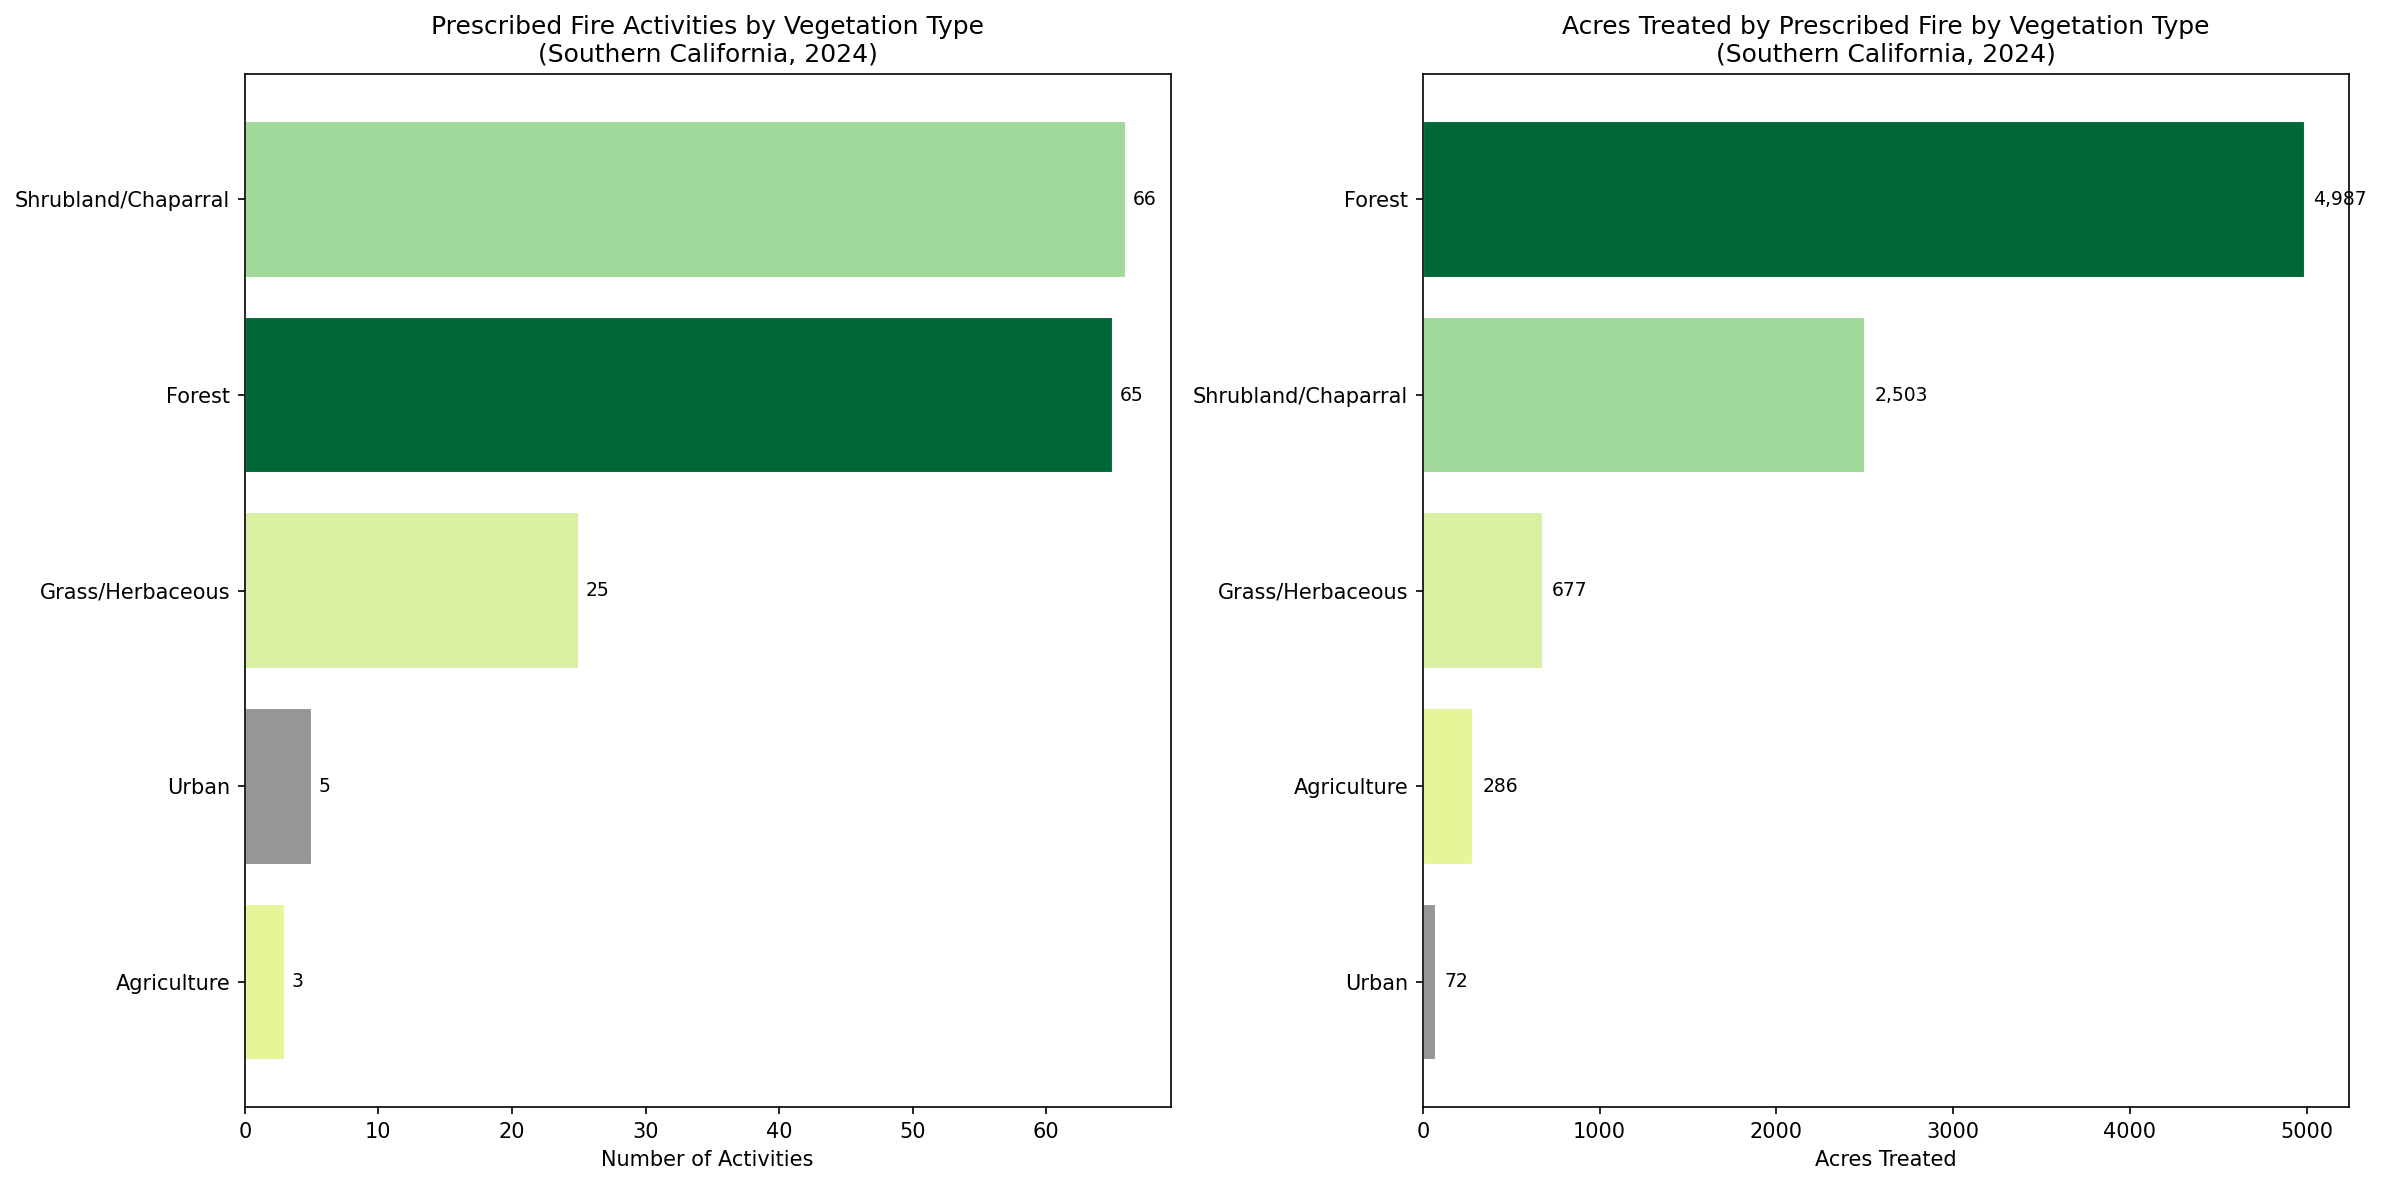

Data source: California Interagency Tracking System (ITS V2.0) via the ArcGIS Feature Service hosted at sparcal.sdsc.edu.

In [ ]:
%%ask
Show me all prescribed fire activities in Southern California from 2024,
colored by vegetation types.

## CALFIRE Treatment Activities in San Diego County: 2023 vs 2024

### Overview

| Metric | 2023 | 2024 | Change |
|---|---|---|---|
| **Total activities** | 144 | 277 | +92% |
| **Total acres treated** | 3,461.5 | 2,657.0 | −23% |
| **Activity categories** | 3 | 2 | Tree Planting dropped in 2024 |
| **Vegetation types treated** | 2 | 3 | Grass/Herbaceous added in 2024 |

### Activity Category Breakdown

| Category | 2023 Count | 2024 Count | 2023 Acres | 2024 Acres |
|---|---|---|---|---|
| Mech. & Hand Fuels Reduction | 131 | 238 | 1,918 | 1,791 |
| Prescribed Fire | 10 | 39 | 1,191 | 866 |
| Tree Planting | 3 | 0 | 353 | 0 |

Key observations:
- **Activity count nearly doubled** in 2024 (277 vs 144), driven by a large increase in both mechanical fuels reduction (+82%) and prescribed fire (+290%).
- **Total acres treated declined 23%** despite more activities, suggesting smaller average treatment sizes in 2024.
- **Prescribed fire activities quadrupled** from 10 to 39, though total prescribed-fire acreage fell from 1,191 to 866 acres.
- **Tree Planting disappeared** in 2024 (3 activities / 353 acres in 2023 → 0 in 2024).

### Vegetation Type Breakdown

| Vegetation Type | 2023 Count | 2024 Count | 2023 Acres | 2024 Acres |
|---|---|---|---|---|
| Shrubland/Chaparral | 120 | 262 | 2,309 | 1,978 |
| Forest | 24 | 11 | 1,152 | 665 |
| Grass/Herbaceous | 0 | 4 | 0 | 14 |

- **Shrubland/Chaparral** dominates both years, consistent with San Diego's landscape. It more than doubled in activity count but acres dropped 14%.
- **Forest treatments halved** in both count (24→11) and acres (1,152→665).
- **Grass/Herbaceous** appeared as a new treatment target in 2024, though at very small scale (4 activities, 14 acres).

### Status Breakdown

| Status | 2023 | 2024 |
|---|---|---|
| Complete | 78 | 114 |
| Active | 66 | 163 |

- 2024 has far more activities still in **Active** status (163 vs 66), likely because many 2024 treatments are still underway or recently initiated.

### Charts


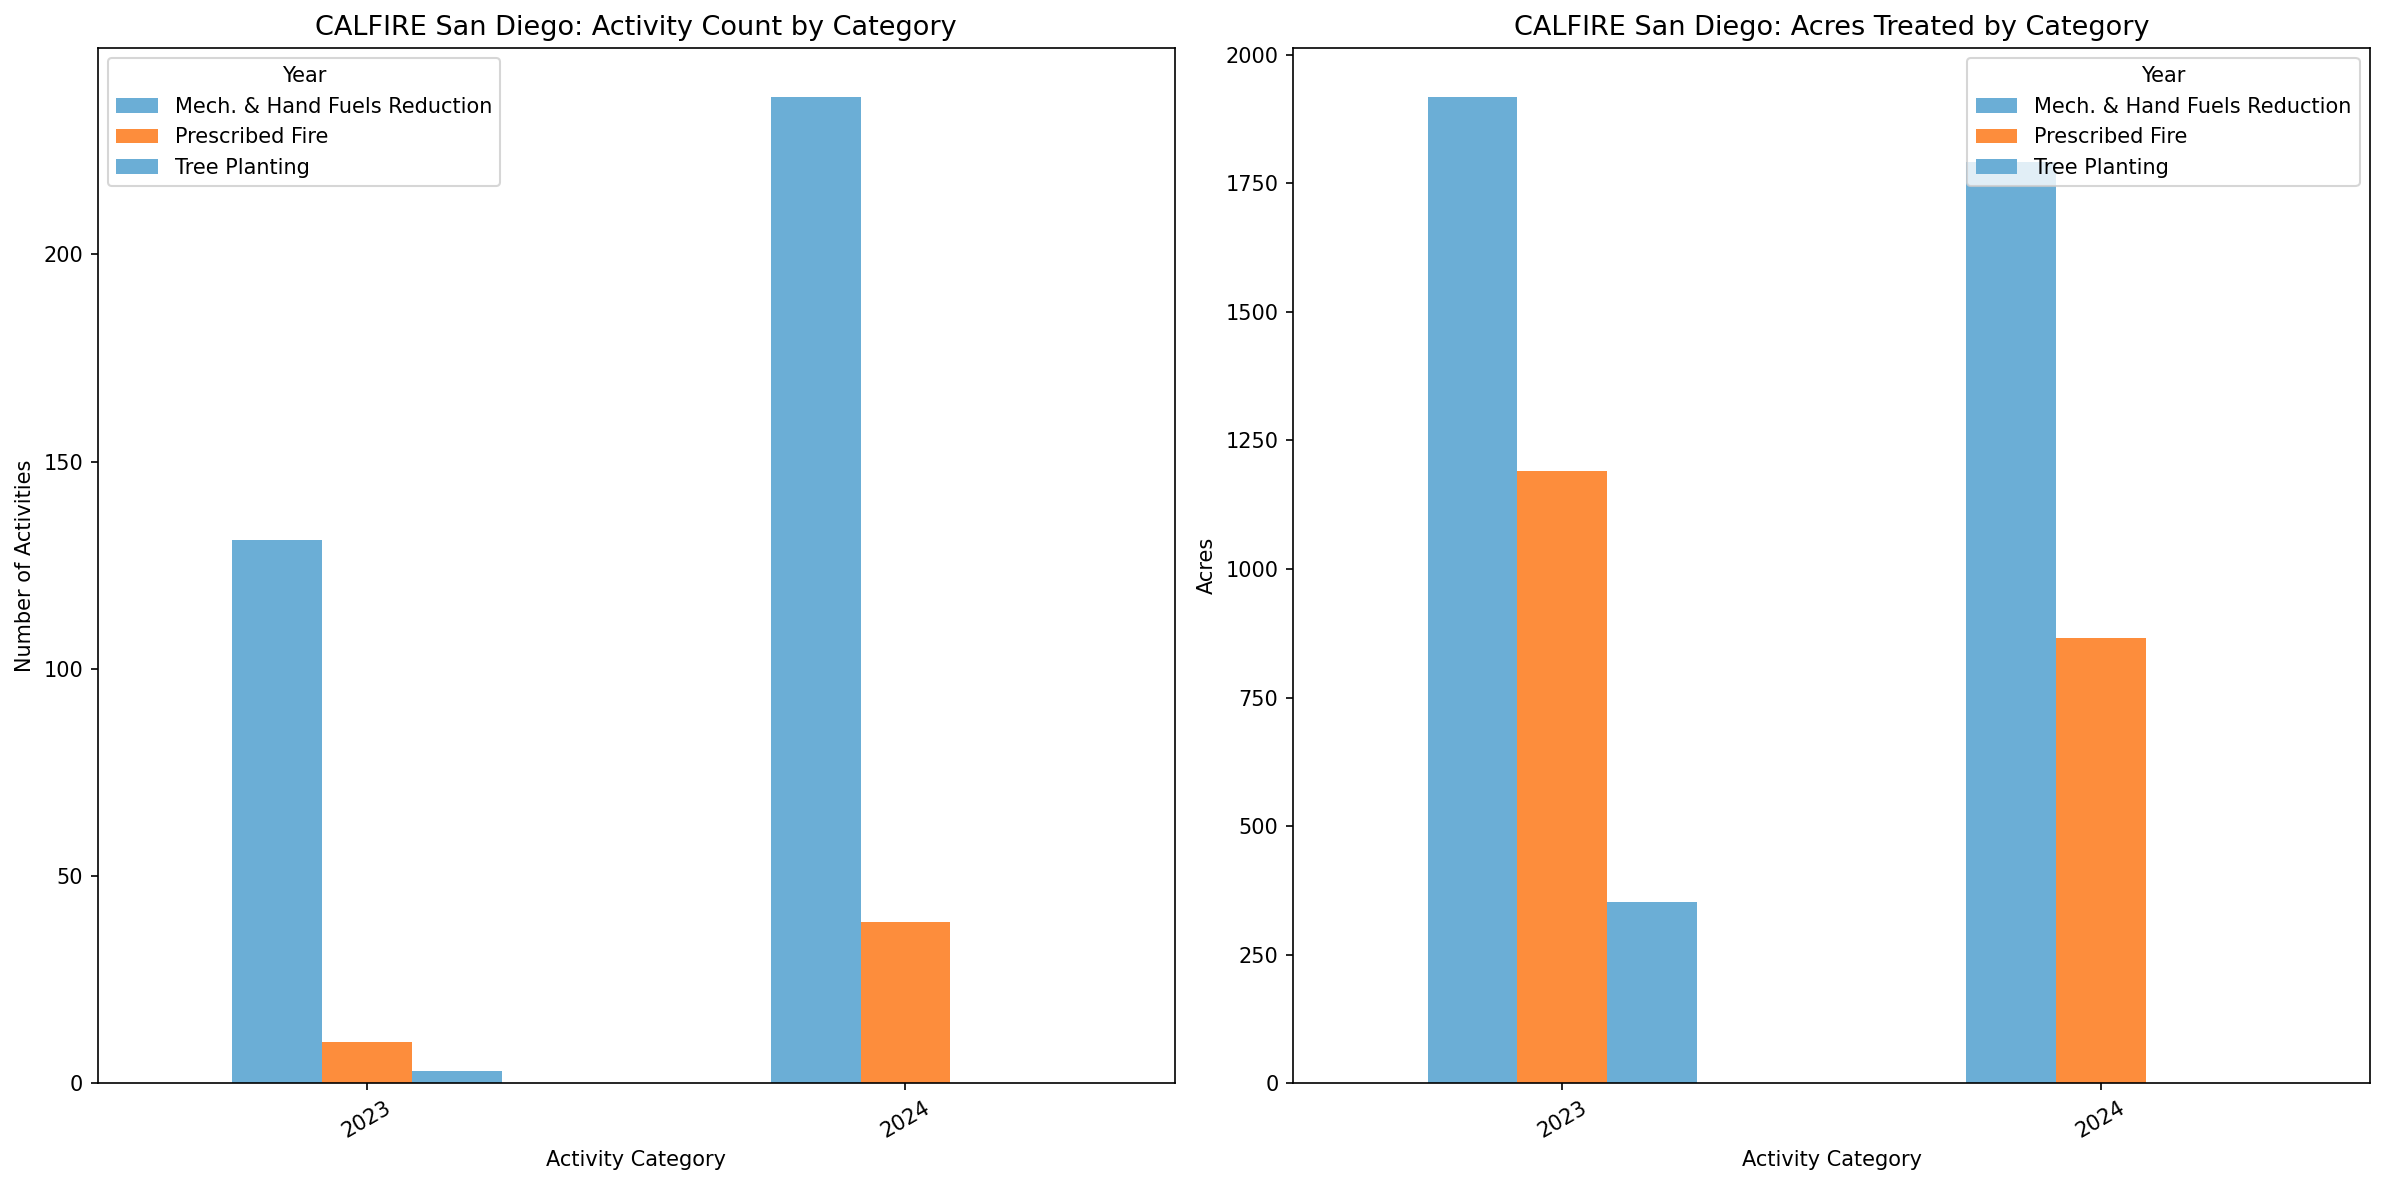


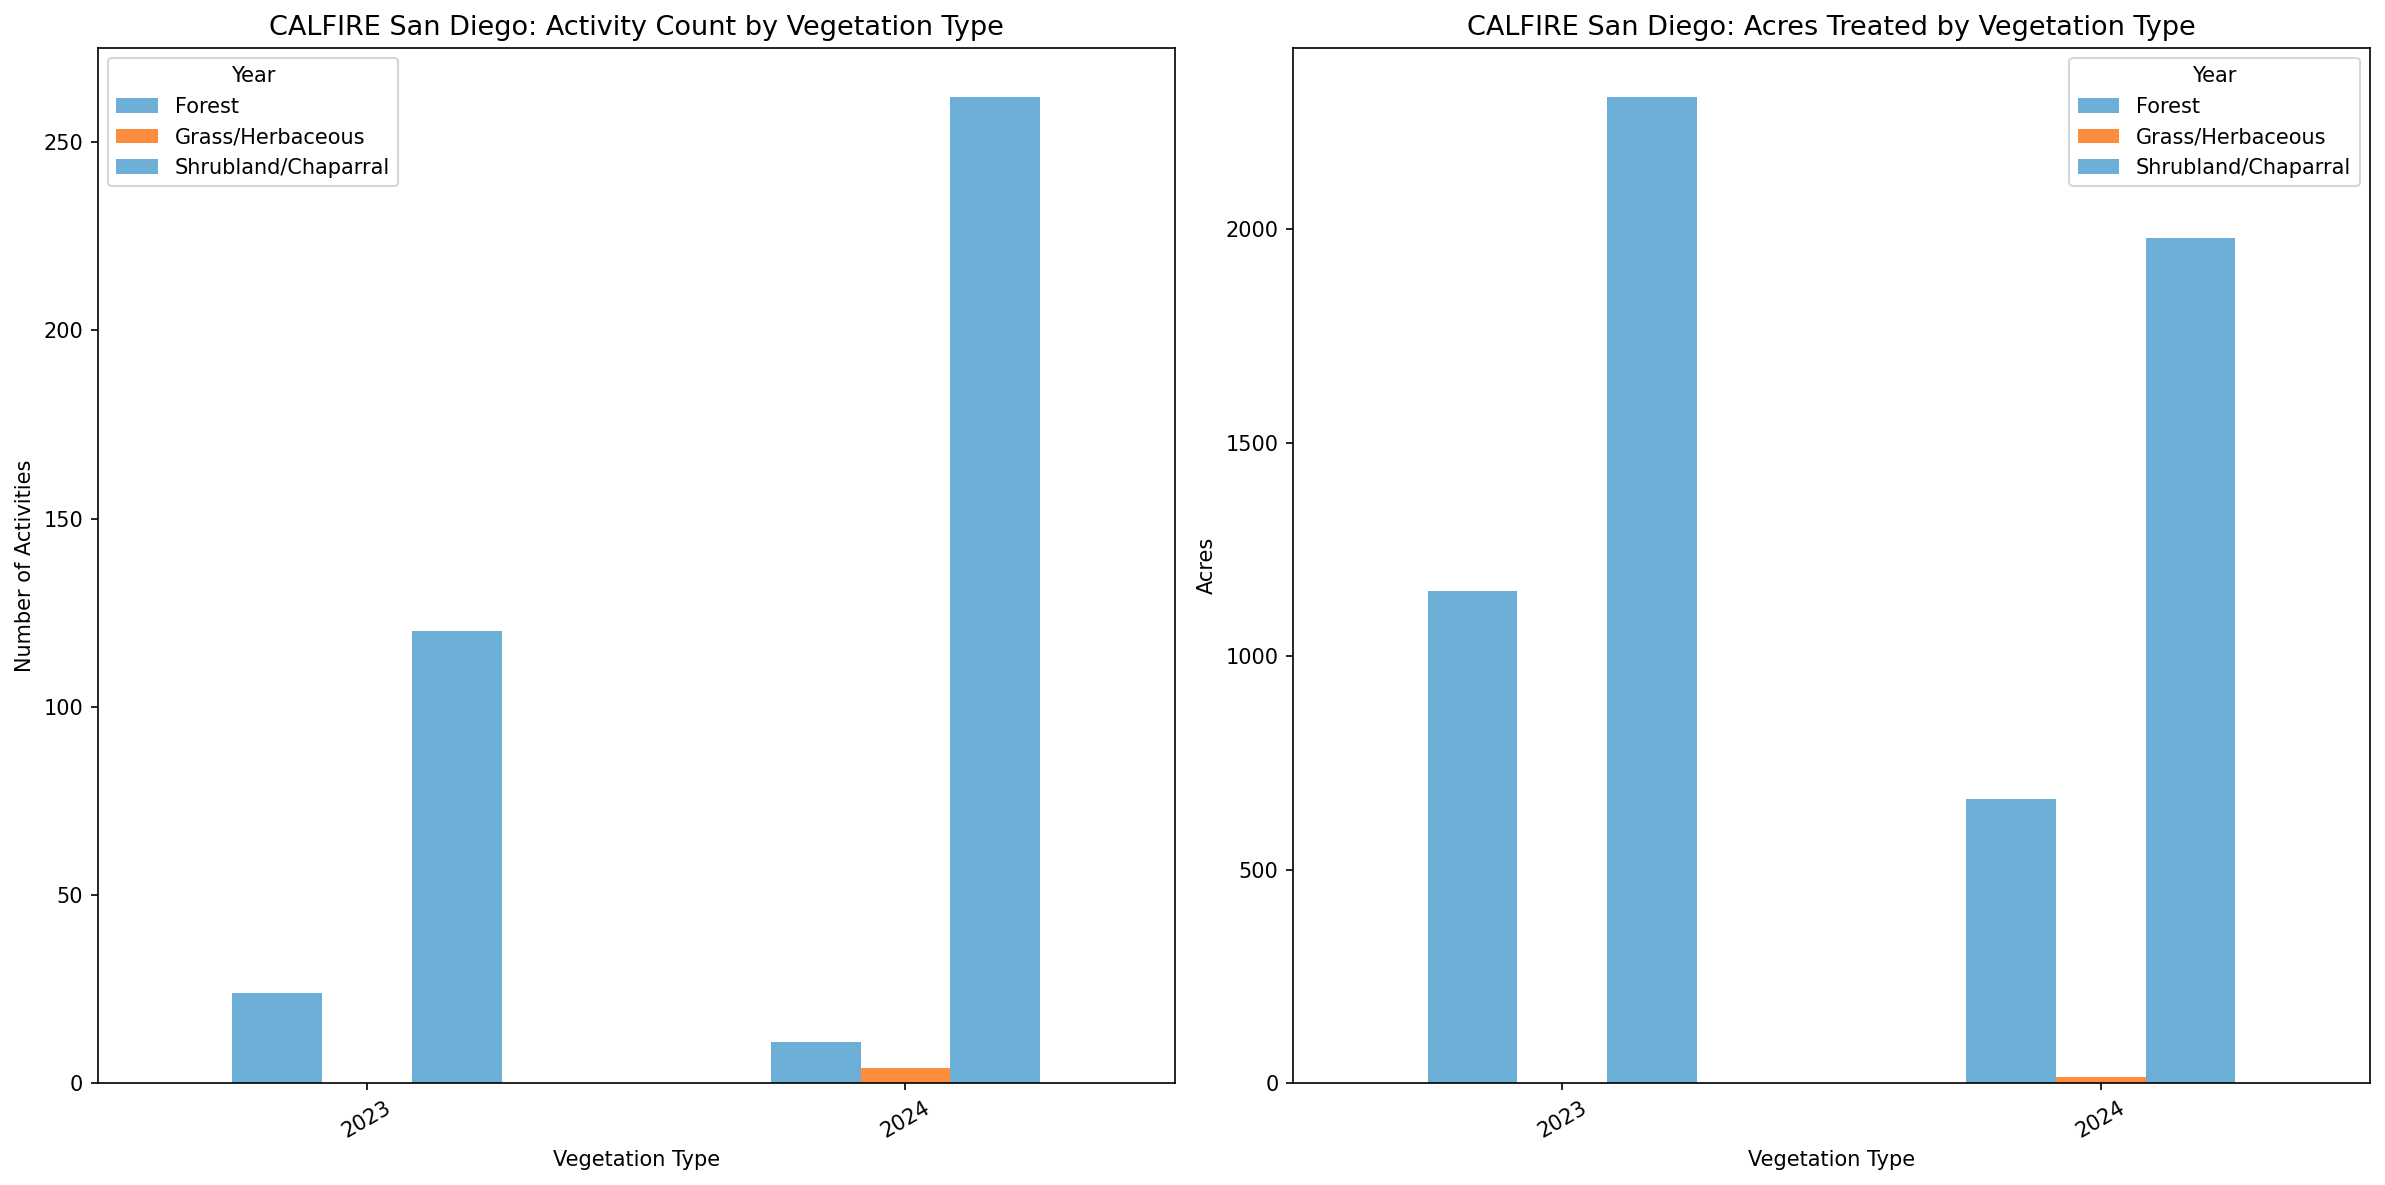


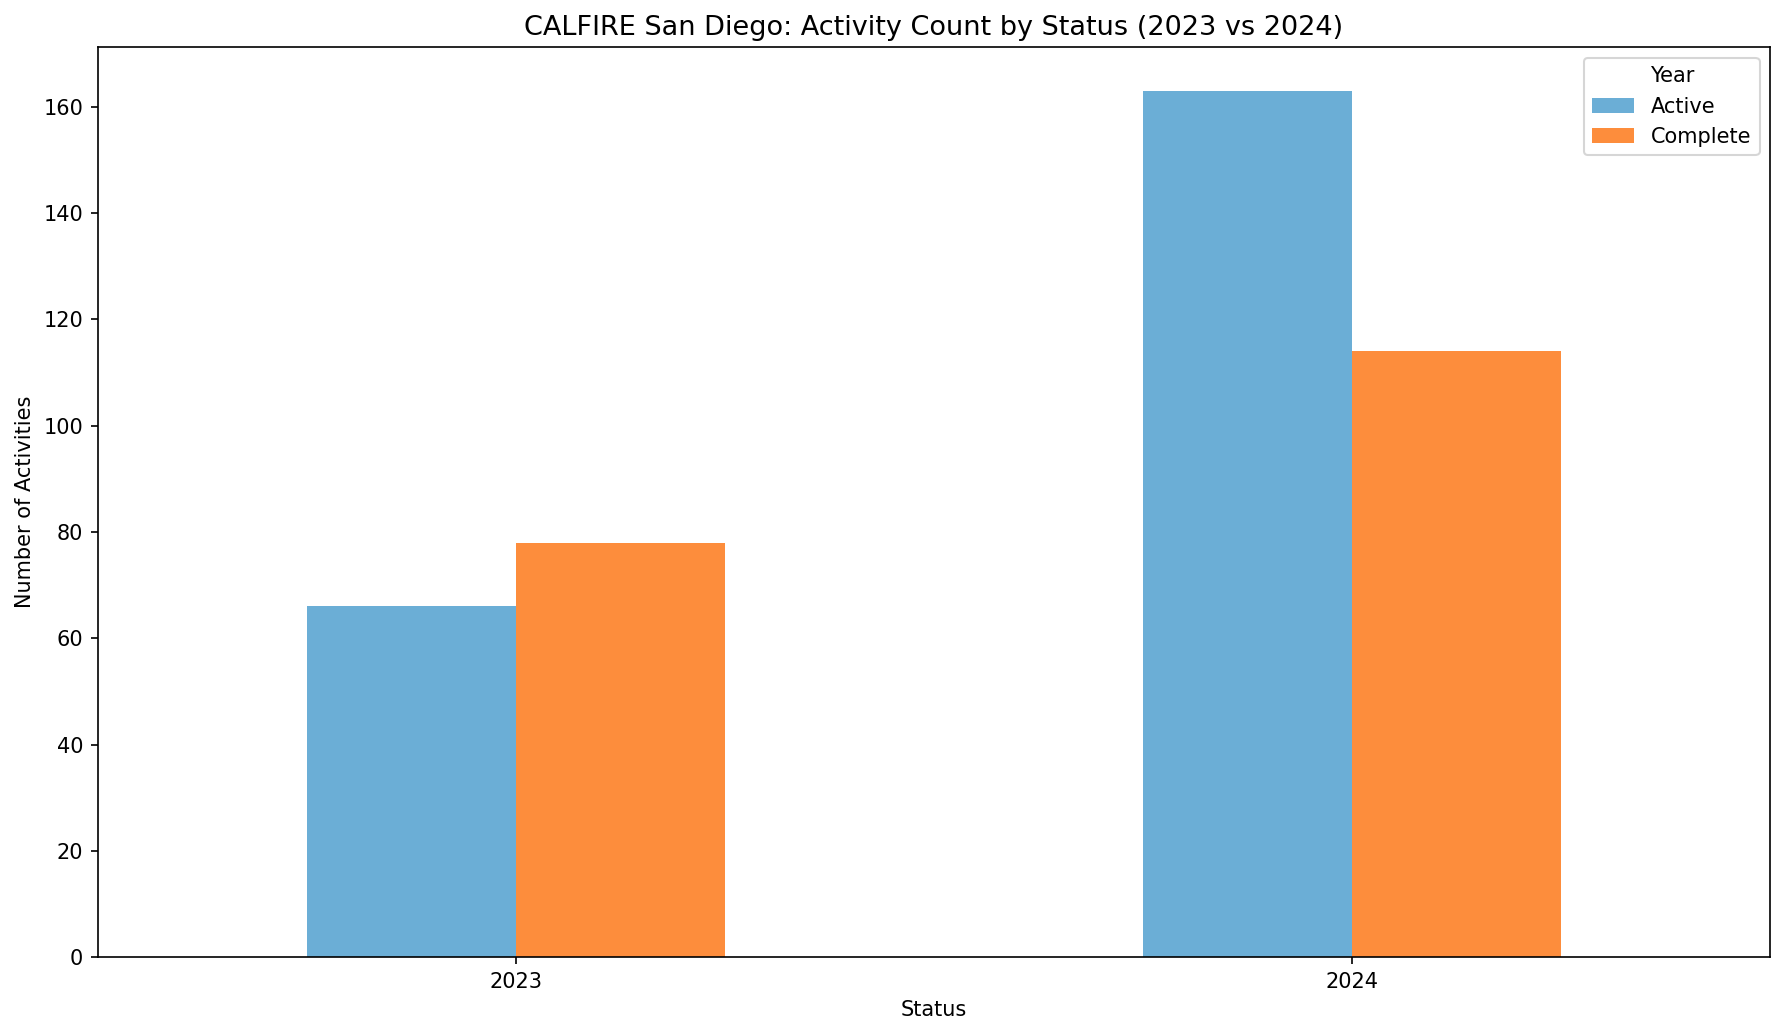

### Map

Data source: California Interagency Tracking System (ITS V2.0) via ArcGIS Feature Service at sparcal.sdsc.edu.

All tasks complete. The comparison reveals that CALFIRE's San Diego operations shifted significantly between 2023 and 2024: many more individual treatment activities in 2024 (especially prescribed fire), but covering fewer total acres, with a strong focus on shrubland/chaparral landscapes.

In [ ]:
%%ask
Compare CALFIRE treatment actvities in San Diego county in 2023 and 2024.

Here are the **top 3 California counties by total treatment acres in 2024** :

| Rank | County | Treatment Acres |
|------|--------|----------------|
| 1 | **Siskiyou** | 92,785 |
| 2 | **Del Norte** | 62,338 |
| 3 | **Tehama** | 51,773 |

These three Northern California counties together account for over **206,896 acres** of vegetation treatment activity in 2024, out of 45,600 individual acreage-measured activities statewide.


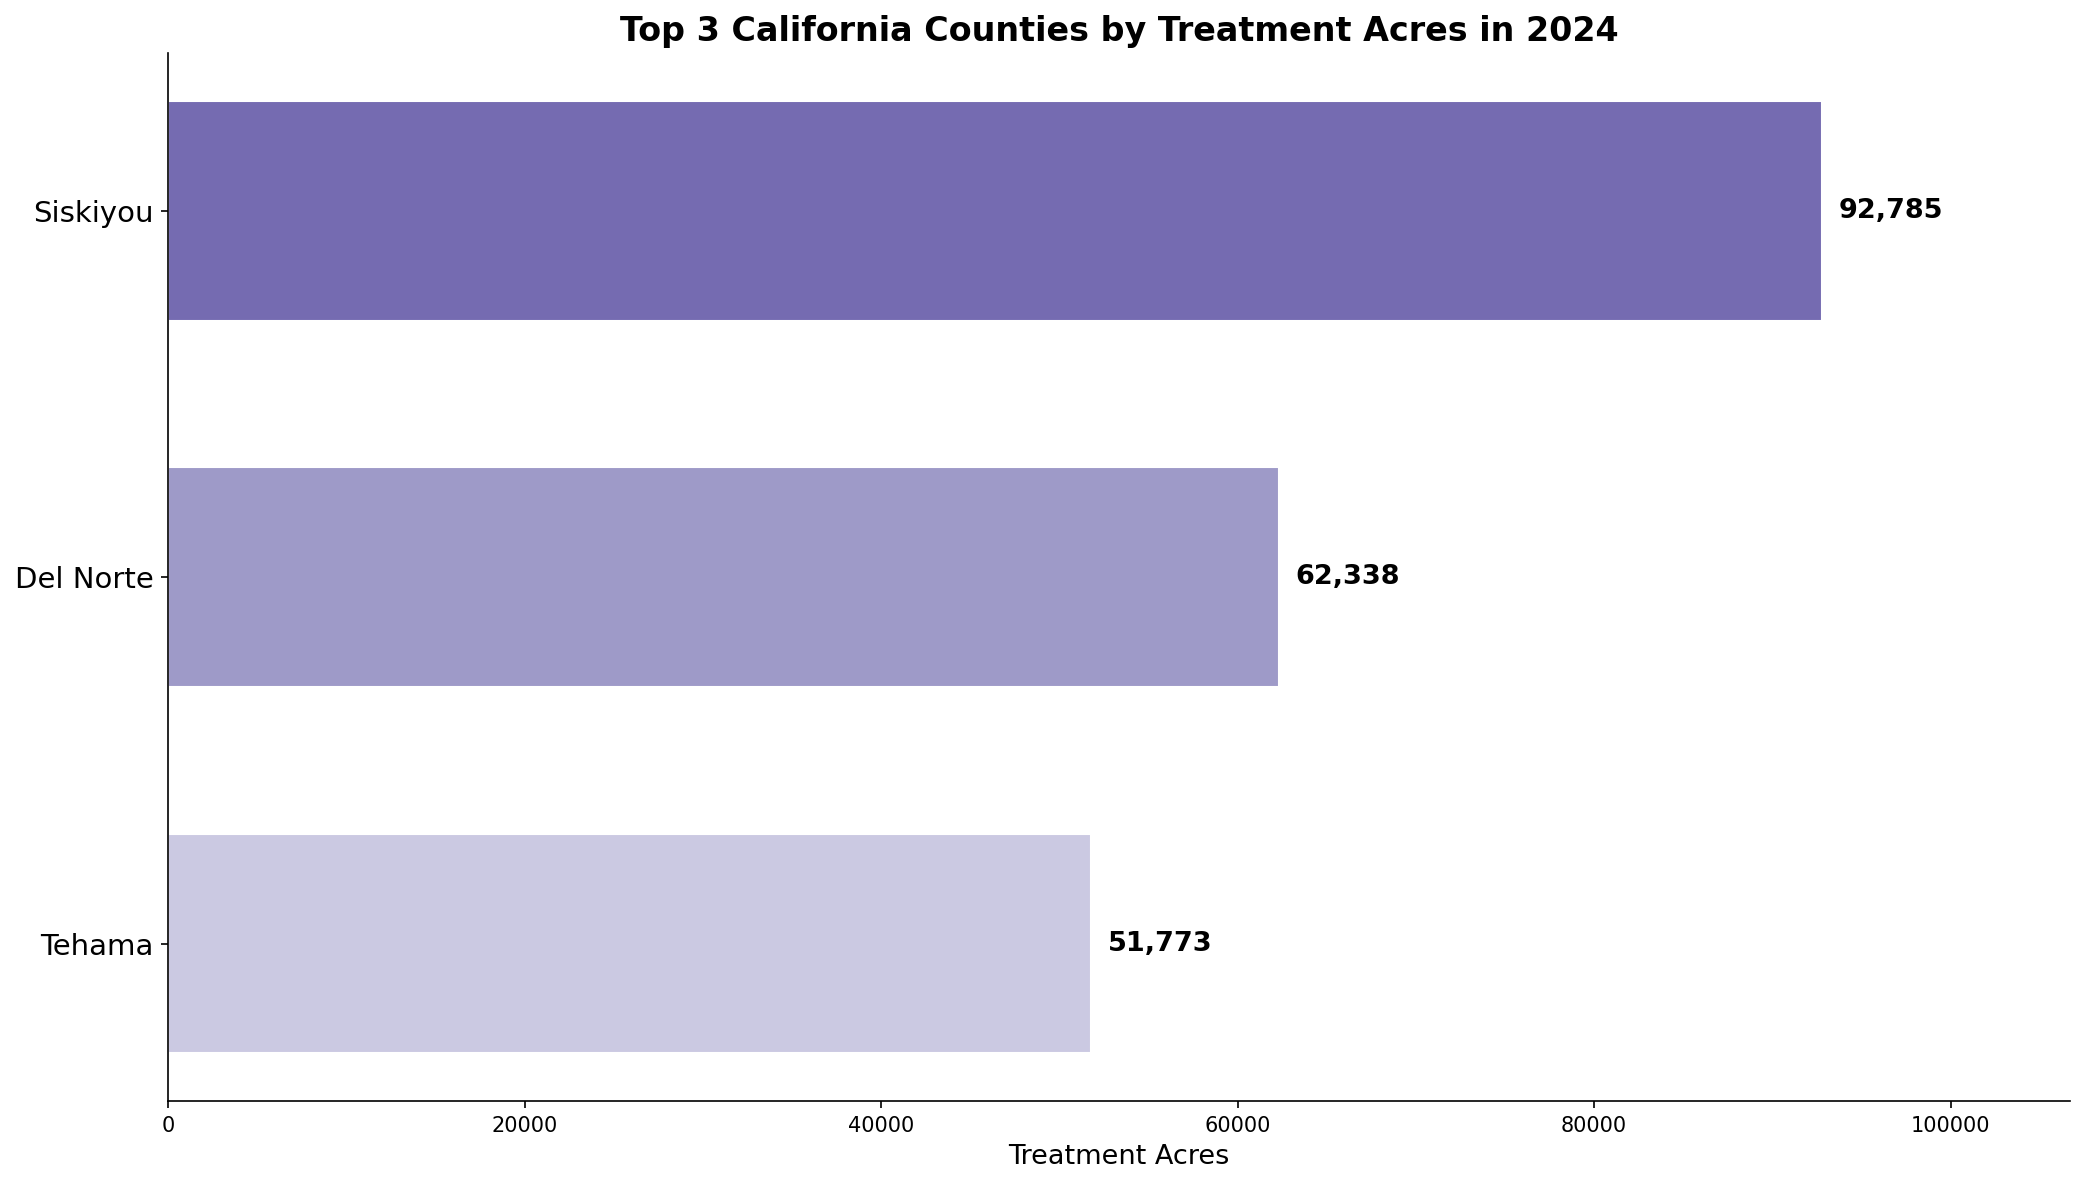

**Key observations:**
- **Siskiyou County** leads by a wide margin (~93K acres), nearly 50% more than the second-place county — reflecting heavy timber harvest and mechanical fuels reduction activity in the Klamath National Forest area.
- **Del Norte** and **Tehama** round out the top 3, both also in the forested northern part of the state where large-scale federal (USFS) and private industrial timber treatments dominate.
- All three top counties are in Northern California, where large parcel sizes and extensive federal forest land enable bigger treatment footprints compared to Southern and coastal counties.

In [ ]:
%%ask
which top 3 counties have the maximum treatment acres in 2024?
Please show the county full names and visualize the result.